# GOES-18 ABI Mesoscale 1 — data, full extent, and a domain

How to load the Mesoscale 1 product from a local folder, plot the **complete
scan**, then choose a **domain** and plot just that.

The Mesoscale 1 scan used here is from 3 October 2023. Mesoscale sectors are small and are moved by forecasters; this one sits off western Mexico at this time.


## Environment

Everything runs in the environment described by
[`environment.yml`](../environment.yml) at the repository root:

```bash
conda env create -f environment.yml
conda activate goes-viirs
python -m jupyter lab
```


## Setup

In [1]:
import logging
import sys
import warnings
from pathlib import Path

from IPython.display import Image, display
from satpy import Scene
from satpy.utils import PerformanceWarning

logging.getLogger("pyspectral.rsr_reader").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.domains import DOMAINS
from examples.goes18_coverage_data import SCAN_LABELS, download_coverage
from examples.render_satellite import (
    crop_and_resample_scene,
    resample_to_max_size,
    save_band_map,
    save_dataset_with_lonlat_grid,
    save_map,
)


## 1. Get the data

The Mesoscale 1 files for this scan and the channels we want.

In [2]:
COVERAGE = "mesoscale"
CHANNELS = ("C13",)

# Where the NetCDF files live. download_coverage() fetches anything missing
# from the public NOAA bucket and reuses whatever is already on disk.
DATA_DIR = REPO_ROOT / "data" / "goes18-20231003-1900"
files = download_coverage(DATA_DIR, COVERAGE, CHANNELS)

print(f"folder: {DATA_DIR / COVERAGE}")
print(f"{len(files)} file(s):")
for name in files:
    print("  ", Path(name).name)


folder: /Users/rmsm1/Desktop/Shishaldin_paper/GOES-VIIRS-Imagery-Guide/data/goes18-20231003-1900/mesoscale
1 file(s):
   OR_ABI-L1b-RadM1-M6C13_G18_s20232761900279_e20232761900348_c20232761900391.nc


## 2. Plot the complete Mesoscale 1 scan

No domain: the whole product is shown on its own grid, only reduced in size so
it is quick to draw.


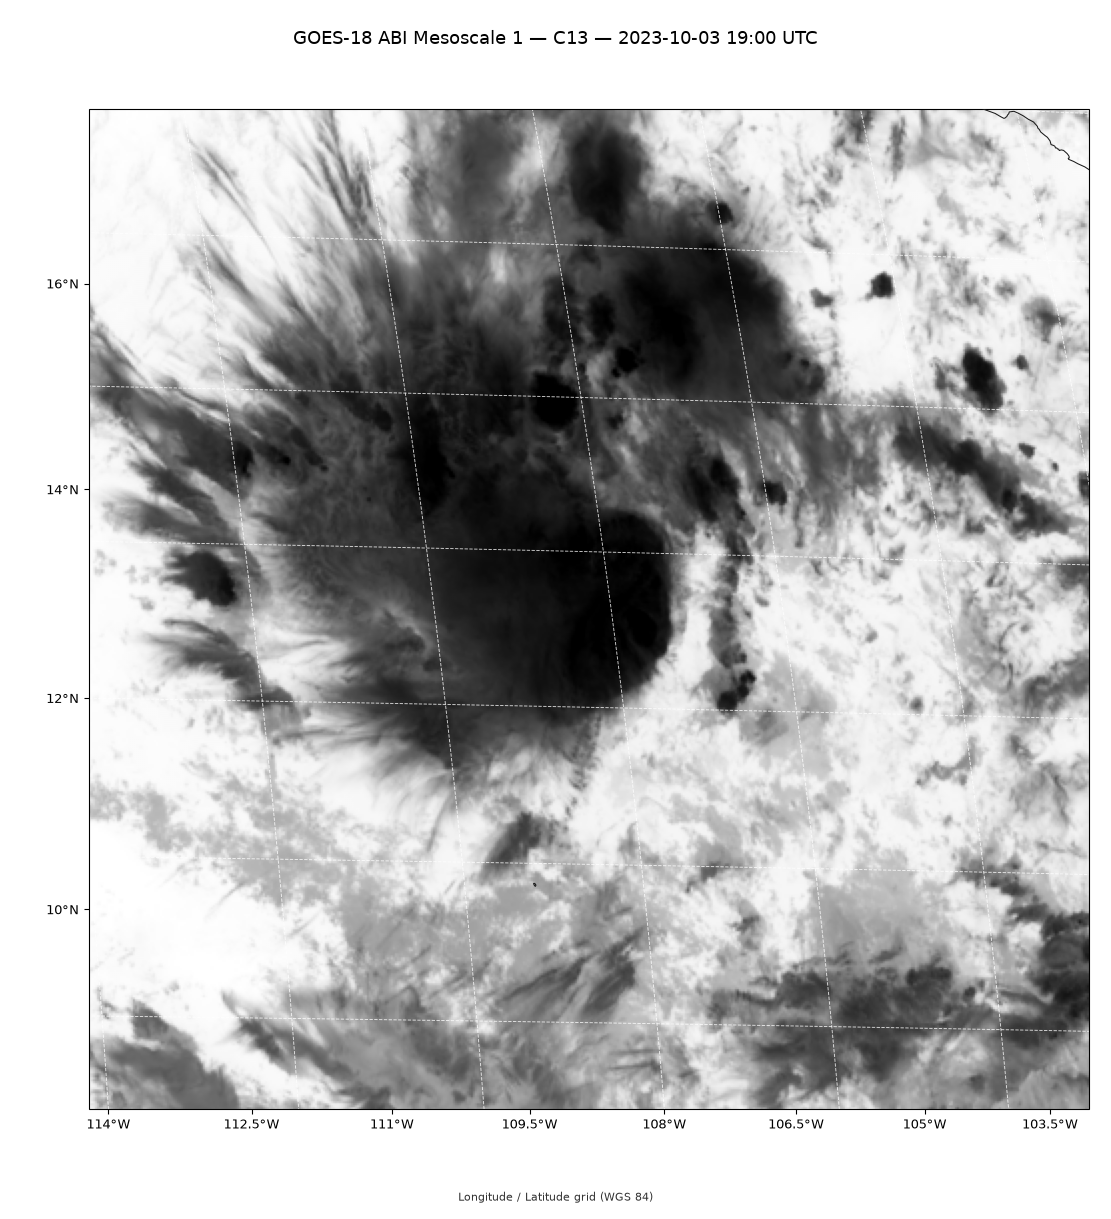

In [3]:
BAND = "C13"          # 10.3 um infrared window
scene = Scene(reader="abi_l1b", filenames=files)
scene.load([BAND])

full = resample_to_max_size(scene, BAND, max_size=1400)
out_full = REPO_ROOT / "output" / "mesoscale_full_C13.png"
save_dataset_with_lonlat_grid(
    full, BAND, out_full,
    title=f"GOES-18 ABI Mesoscale 1 — {BAND} — {SCAN_LABELS['mesoscale']}",
    dpi=100,
)
display(Image(filename=str(out_full)))


## 3. Choose a domain

Named domains live in [`examples/domains.py`](../examples/domains.py). Pick one,
or set `DOMAIN` to your own `(min_lon, min_lat, max_lon, max_lat)` box.

The box must fall **inside** the Mesoscale 1 coverage — a crop cannot invent data
that the product never observed.


In [4]:
DOMAIN_NAME = "mesoscale_example"
DOMAIN = DOMAINS[DOMAIN_NAME]
RESOLUTION = 0.02

print(f"{DOMAIN_NAME}: {DOMAIN}")


mesoscale_example: (-112.0, 10.0, -104.0, 17.0)


## 4. Plot that domain

Cropped to the box, on a regular lon/lat grid with a colour bar.

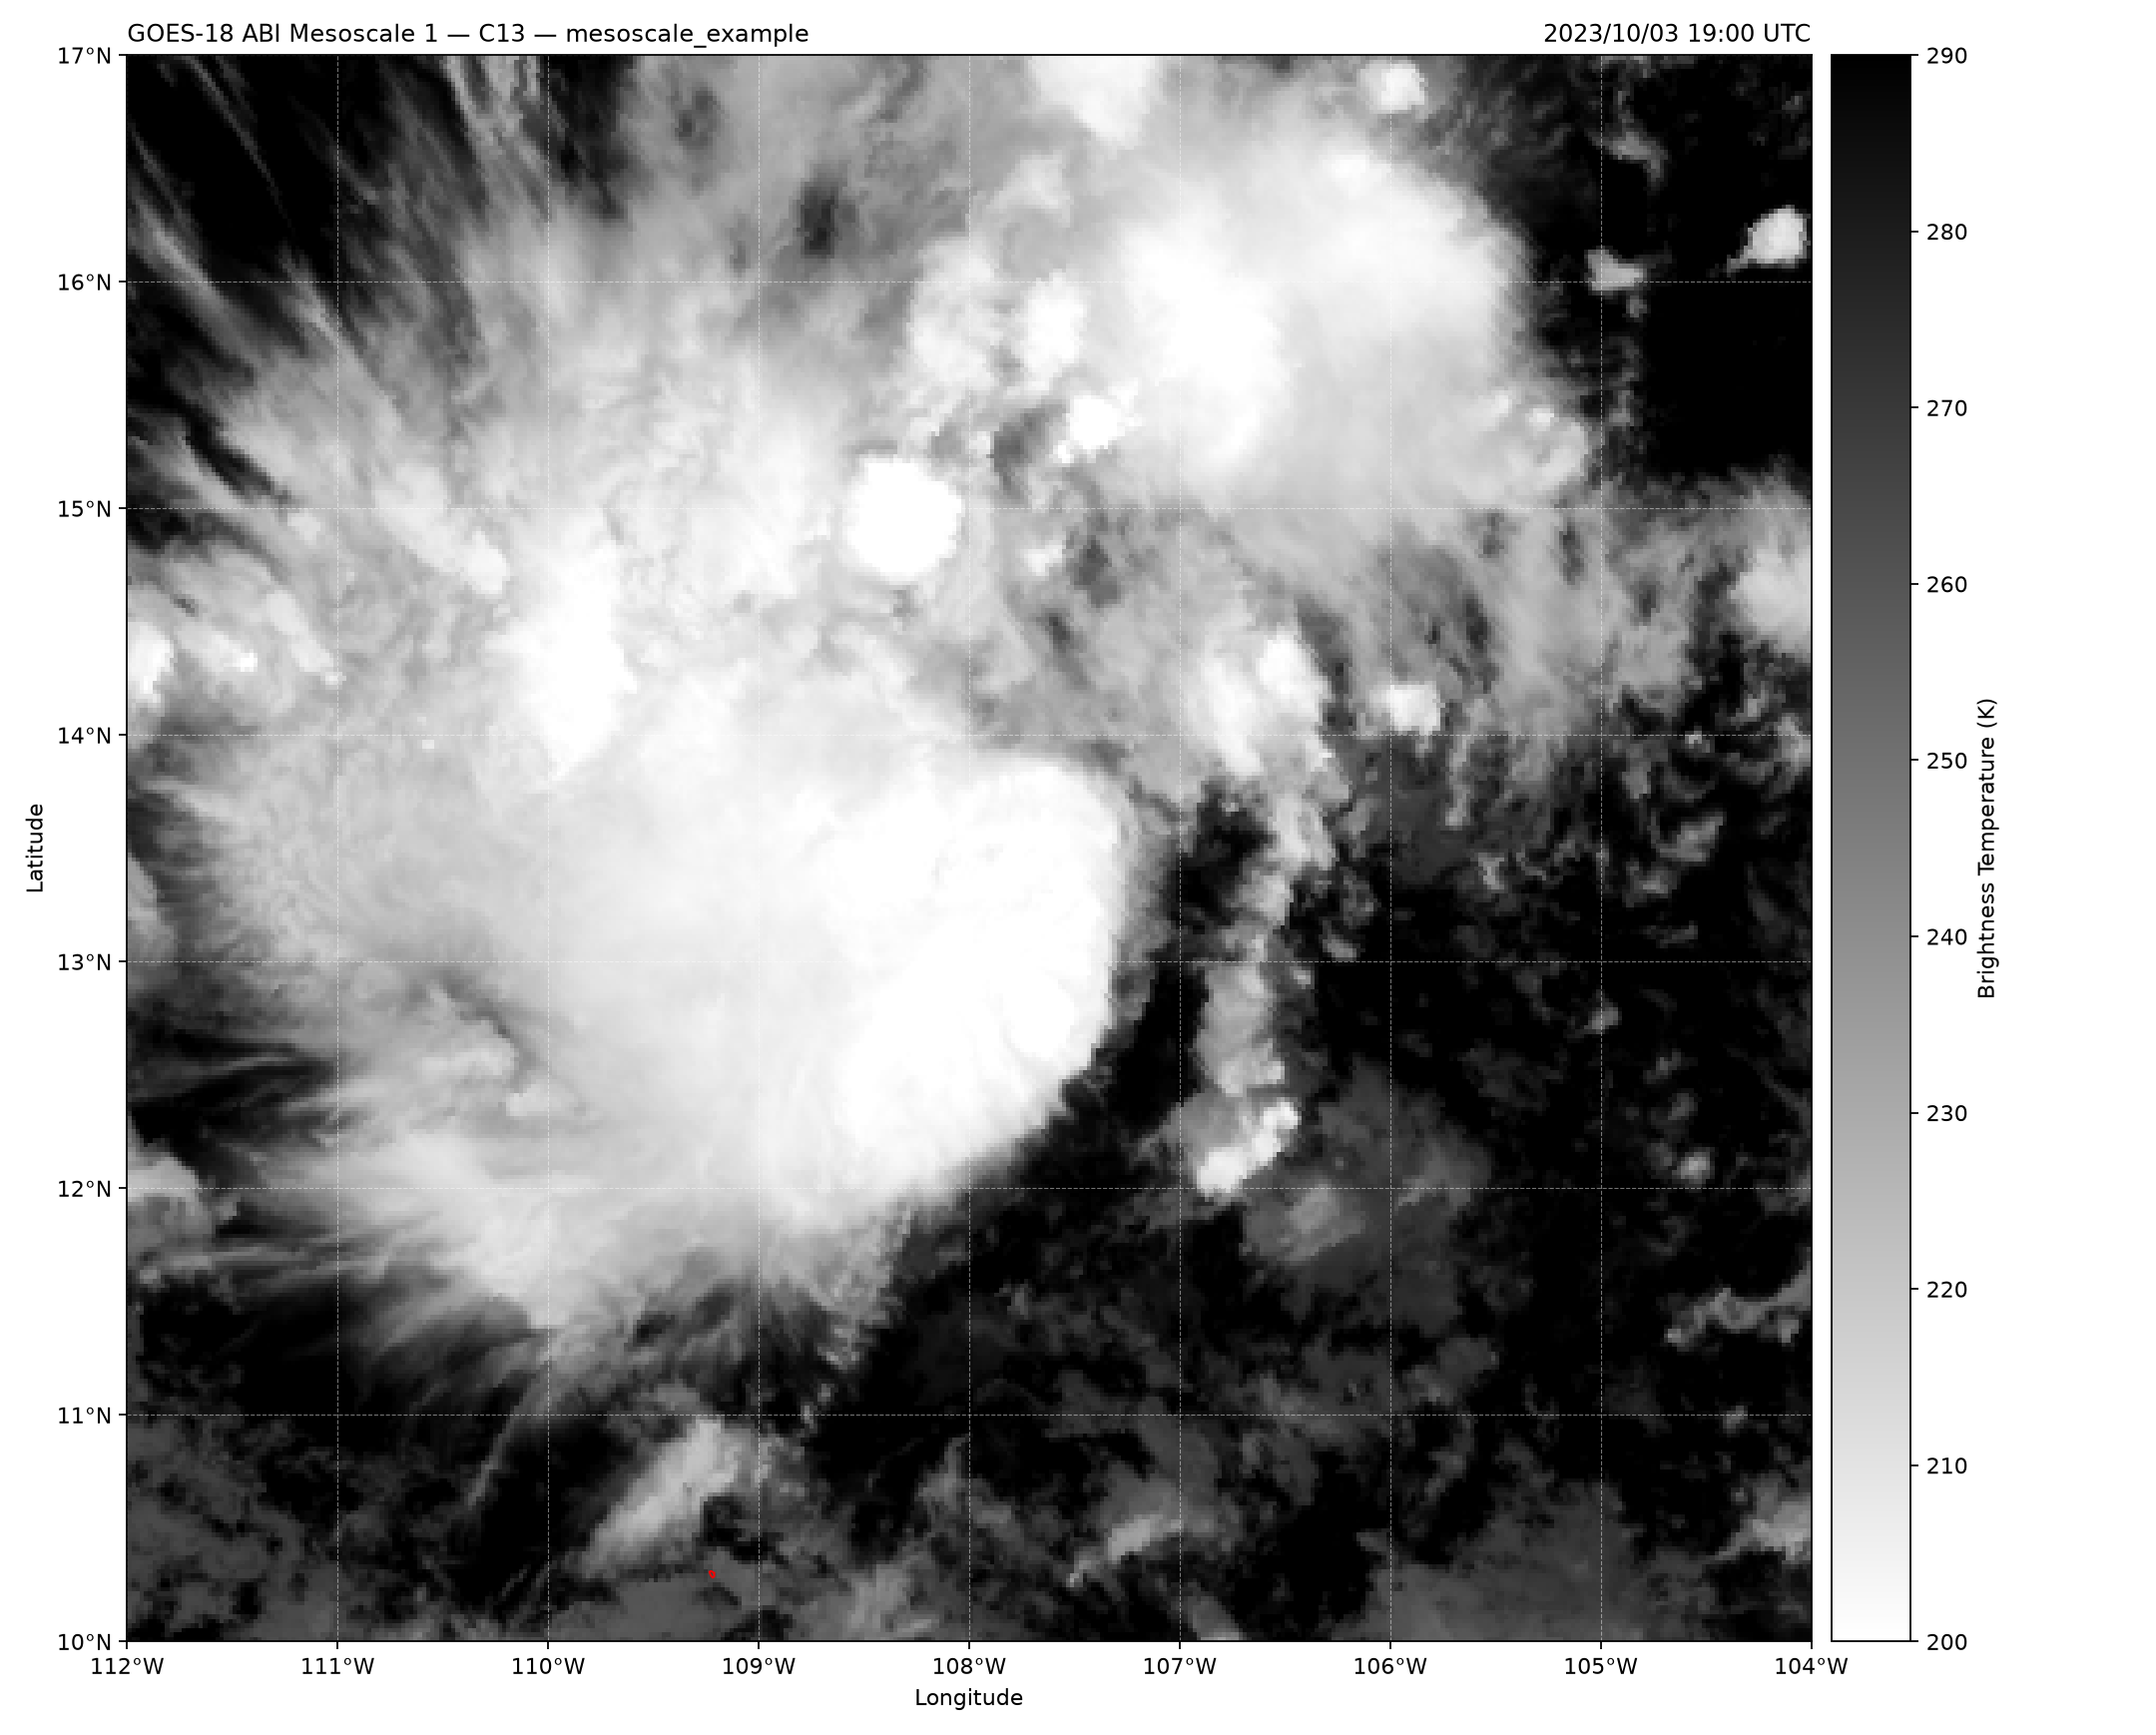

In [5]:
cropped = crop_and_resample_scene(scene, domain=DOMAIN, resolution=RESOLUTION)
out_domain = REPO_ROOT / "output" / "mesoscale_domain_C13.png"
save_band_map(
    cropped, BAND, out_domain,
    title=f"GOES-18 ABI Mesoscale 1 — {BAND} — {DOMAIN_NAME}",
    cmap="gray_r", vmin=200, vmax=290,
    colorbar_label="Brightness Temperature (K)",
)
display(Image(filename=str(out_domain)))


## Notes

* Omit the domain to keep the complete product; give one to zoom in.
* `download_coverage()` only downloads what is missing, so re-running is cheap.
